# Medical Imaging + AI (Segmentation) — Exercises & Solutions

This notebook is designed to get you productive with medical-imaging workflows and deep-learning segmentation.

## Topics
- Visualization: **windowing**, overlays
- Data: datasets, splits, **paired augmentations** (image+mask)
- Models: a minimal **2D U-Net**
- Losses & metrics: **BCE**, **Dice**, IoU
- Training loop + evaluation
- Inference + simple post-processing
- **Interpretability: Grad-CAM for understanding model predictions**

## How to use
- Each section has an **Exercise** cell (TODOs) and a **Solution** cell.
- The notebook runs without external data via a **synthetic dataset** fallback.

In [ ]:
import os
import math
import random
from dataclasses import dataclass
from typing import Dict, Tuple, Optional
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF

def seed_everything(seed: int = 0) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cpu


In [13]:
# Configure dataset paths with automatic zip extraction
def extract_kvasir_zip() -> str:
    """
    Automatically extract Kvasir-SEG.zip from the data folder.
    
    Returns:
        Path to the extracted Kvasir-SEG folder
    """
   
    notebook_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
    project_root = notebook_dir.parent
    data_dir = project_root / 'data'
    
    target_dir = data_dir / 'Kvasir-SEG'
    zip_path = data_dir / 'Kvasir-SEG.zip'
    

    if target_dir.exists() and (target_dir / 'images').exists():
        print(f'Dataset found at: {target_dir}')
        return str(target_dir)
    
    if not zip_path.exists():
        print(f'✗ Kvasir-SEG.zip not found at: {zip_path}')
        print('  Please place Kvasir-SEG.zip in the data folder.')
        print('  Download from: https://datasets.simula.no/kvasir-seg/')
        return str(target_dir)
    
    # Extract the zip file
    print(f'Found zip file at: {zip_path}')
    print(f'Extracting...')
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print(f'Successfully extracted to: {target_dir}')
        return str(target_dir)
    except Exception as e:
        print(f'Error extracting zip file: {e}')
        return str(target_dir)

DATA_ROOT = extract_kvasir_zip()

images_dir = os.path.join(DATA_ROOT, 'images')
masks_dir  = os.path.join(DATA_ROOT, 'masks')

def has_real_dataset(images_dir: str, masks_dir: str) -> bool:
    return os.path.isdir(images_dir) and os.path.isdir(masks_dir)

print('\nDataset configuration:')
print('images_dir:', images_dir)
print('masks_dir :', masks_dir)
print('dataset found:', has_real_dataset(images_dir, masks_dir))

@dataclass
class Batch:
    x: torch.Tensor  # [B,3,H,W]
    y: torch.Tensor  # [B,1,H,W] (binary)

✓ Found zip file at: /Users/giuliamonopoli/Desktop/sscp_material/medical-imaging-segmentation-notebook/data/Kvasir-SEG.zip
Extracting...
✓ Successfully extracted to: /Users/giuliamonopoli/Desktop/sscp_material/medical-imaging-segmentation-notebook/data/Kvasir-SEG

Dataset configuration:
images_dir: /Users/giuliamonopoli/Desktop/sscp_material/medical-imaging-segmentation-notebook/data/Kvasir-SEG/images
masks_dir : /Users/giuliamonopoli/Desktop/sscp_material/medical-imaging-segmentation-notebook/data/Kvasir-SEG/masks
dataset found: True


##  Medical image formats (DICOM / NIfTI) 

Many medical datasets store pixel data in:
- **DICOM**: clinical standard; metadata-heavy; slices/series.
- **NIfTI**: common for research; 3D/4D volumes; simple header.



##  Datasets: image/mask pairs + binarization

### Exercise
Implement a dataset that:
- loads an image as RGB and a mask as grayscale
- converts both to tensors
- returns `image: [3,H,W]` and `mask: [1,H,W]` where mask is binary `{0,1}`
- **IMPORTANT**: resizes both to a fixed target size so batches can be stacked

In [34]:
# Exercise (TODO)
class ImageMaskFolderDataset(Dataset):
    def __init__(self, image_paths, mask_paths, target_size: Optional[Tuple[int, int]] = None):
        assert len(image_paths) == len(mask_paths)
        self.image_paths = list(image_paths)
        self.mask_paths = list(mask_paths)
        self.target_size = target_size  # e.g., (192, 192)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        # TODO: load PIL image + mask
        # TODO: if mask size != image size, resize mask to match image first
        # TODO: if target_size is set, resize both to target_size (image: bilinear, mask: nearest)
        # TODO: convert to tensors
        # TODO: binarize mask
        raise NotImplementedError

def binarize_mask(mask01: torch.Tensor, thr: float = 0.5) -> torch.Tensor:
    """mask01: [1,H,W] float in [0,1] -> {0,1}."""
    # TODO
    raise NotImplementedError

In [14]:
# Solution
def binarize_mask(mask01: torch.Tensor, thr: float = 0.5) -> torch.Tensor:
    return (mask01 >= thr).float()

class ImageMaskFolderDataset(Dataset):
    def __init__(self, image_paths, mask_paths, target_size: Optional[Tuple[int, int]] = None):
        assert len(image_paths) == len(mask_paths)
        self.image_paths = list(image_paths)
        self.mask_paths = list(mask_paths)
        self.target_size = target_size
        self.to_tensor = T.ToTensor()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        msk = Image.open(self.mask_paths[idx]).convert('L')

        # Safety: align mask to image size if they differ
        if msk.size != img.size:
            msk = msk.resize(img.size, resample=Image.NEAREST)

        # Critical: resize to fixed size so DataLoader can batch
        if self.target_size is not None:
            img = img.resize(self.target_size, resample=Image.BILINEAR)
            msk = msk.resize(self.target_size, resample=Image.NEAREST)

        x = self.to_tensor(img)                # [3,H,W] in [0,1]
        y = self.to_tensor(msk)                # [1,H,W] in [0,1]
        y = binarize_mask(y, thr=0.5)          # {0,1}
        return x, y

## Paired augmentation (same spatial transform for image & mask)

In segmentation, any spatial transform must be applied **identically** to the image and the mask.

### Exercise
Implement `paired_augment(x, y)` with:
- random horizontal flip (p=0.5)
- random rotation in `[-15°, 15°]`

Constraints:
- `x` is float image tensor `[3,H,W]`
- `y` is binary mask tensor `[1,H,W]`
- masks must use **nearest** interpolation when rotating

In [ ]:
# Exercise (TODO)
def paired_augment(x: torch.Tensor, y: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    # TODO: implement paired flip + paired rotation
    raise NotImplementedError

In [15]:
# Solution
def paired_augment(x: torch.Tensor, y: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    # Flip
    if torch.rand(()) < 0.5:
        x = TF.hflip(x)
        y = TF.hflip(y)

    # Rotate (same angle)
    angle = float(torch.empty(1).uniform_(-15.0, 15.0).item())
    x = TF.rotate(x, angle=angle, interpolation=TF.InterpolationMode.BILINEAR)
    y = TF.rotate(y, angle=angle, interpolation=TF.InterpolationMode.NEAREST)
    y = (y >= 0.5).float()  # keep binary after interpolation
    return x, y

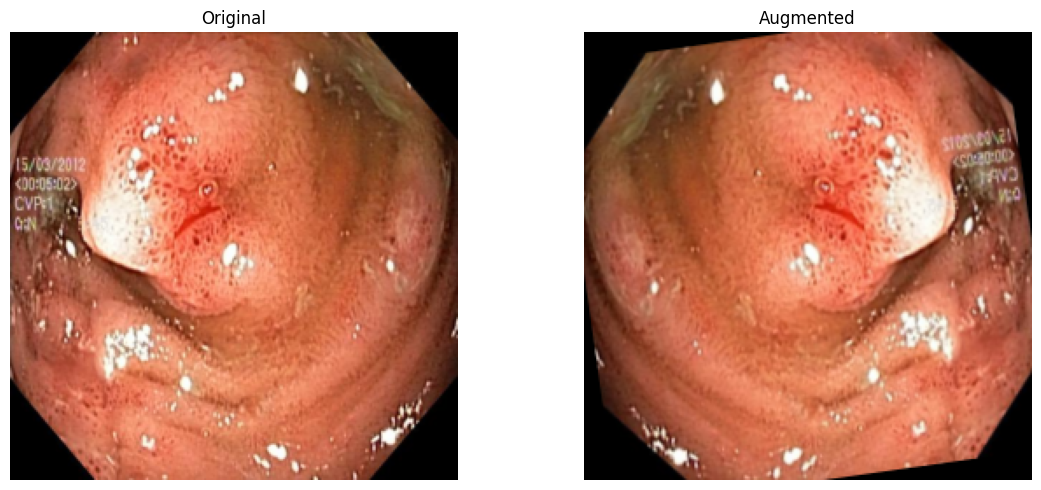

In [16]:
# plot a random augmented sample

from glob import glob


image_paths = sorted(glob(os.path.join(images_dir, '*.jpg')) + glob(os.path.join(images_dir, '*.png')))
mask_paths  = sorted(glob(os.path.join(masks_dir,  '*.jpg')) + glob(os.path.join(masks_dir,  '*.png')))
dataset = ImageMaskFolderDataset(image_paths, mask_paths, target_size=(256, 256))
x, y = dataset[0]
x_aug, y_aug = paired_augment(x, y)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.title('Original'); plt.imshow(x.permute(1, 2, 0)); plt.axis('off')
plt.subplot(1, 2, 2); plt.title('Augmented'); plt.imshow(x_aug.permute(1, 2, 0)); plt.axis('off')
plt.tight_layout(); plt.show()  


## 6) Model: minimal 2D U-Net

### Exercise
Implement `DoubleConv` and finish the forward pass in `UNetSmall`.

Target:
- input: `[B,3,H,W]`
- output logits: `[B,1,H,W]`

In [ ]:
# Exercise (TODO)
class DoubleConv(nn.Module):
    """
    A building block consisting of two convolution layers with BatchNorm and ReLU.
    This is a fundamental component of U-Net architecture.
    """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        # TODO: Create a Sequential module with:
        # 1. Conv2d: in_ch -> out_ch, kernel=3, padding=1, bias=False
        # 2. BatchNorm2d: out_ch
        # 3. ReLU: inplace=False (important for Grad-CAM!)
        # 4. Conv2d: out_ch -> out_ch, kernel=3, padding=1, bias=False
        # 5. BatchNorm2d: out_ch
        # 6. ReLU: inplace=False
        raise NotImplementedError

    def forward(self, x):
        # TODO: pass x through self.net
        raise NotImplementedError

class UNetSmall(nn.Module):
    """
    A minimal U-Net with 3 encoder levels and 2 decoder levels.
    Architecture: Encoder (downsample) -> Bottleneck -> Decoder (upsample with skip connections)
    """
    def __init__(self, in_ch: int = 3, out_ch: int = 1, base: int = 32):
        super().__init__()
        # Encoder path (contracting)
        # TODO: Define encoder blocks
        # enc1: DoubleConv(in_ch -> base)
        # pool1: MaxPool2d(kernel_size=2)
        # enc2: DoubleConv(base -> base*2)
        # pool2: MaxPool2d(kernel_size=2)
        # enc3: DoubleConv(base*2 -> base*4)  # bottleneck
        raise NotImplementedError
        
        # Decoder path (expanding)
        # TODO: Define decoder blocks with upsampling
        # up2: ConvTranspose2d(base*4 -> base*2, kernel=2, stride=2)
        # dec2: DoubleConv(base*4 -> base*2)  # base*4 because of concatenation with enc2
        # up1: ConvTranspose2d(base*2 -> base, kernel=2, stride=2)
        # dec1: DoubleConv(base*2 -> base)    # base*2 because of concatenation with enc1
        raise NotImplementedError
        
        # Output head
        # TODO: head: Conv2d(base -> out_ch, kernel=1)
        raise NotImplementedError

    def forward(self, x):
        """
        Forward pass with skip connections (concatenate encoder features with decoder features)
        Input: [B, 3, H, W]
        Output: [B, 1, H, W] (logits for binary segmentation)
        """
        # Encoder path
        # TODO: 
        # x1 = self.enc1(x)           # [B, base, H, W]
        # x2 = self.enc2(self.pool1(x1))  # [B, base*2, H/2, W/2]
        # x3 = self.enc3(self.pool2(x2))  # [B, base*4, H/4, W/4] - bottleneck
        raise NotImplementedError

        # Decoder path with skip connections
        # TODO:
        # u2 = self.up2(x3)                      # [B, base*2, H/2, W/2]
        # d2 = self.dec2(torch.cat([u2, x2], dim=1))  # concatenate skip connection from enc2
        
        # u1 = self.up1(d2)                      # [B, base, H, W]
        # d1 = self.dec1(torch.cat([u1, x1], dim=1))  # concatenate skip connection from enc1
        
        # return self.head(d1)  # [B, out_ch, H, W]
        raise NotImplementedError

In [17]:
# Solution
class DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=False),  # Changed to False for Grad-CAM compatibility
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=False),  # Changed to False for Grad-CAM compatibility
        )

    def forward(self, x):
        return self.net(x)

class UNetSmall(nn.Module):
    def __init__(self, in_ch: int = 3, out_ch: int = 1, base: int = 32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(base, base * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(base * 2, base * 4)

        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.head = nn.Conv2d(base, out_ch, kernel_size=1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool1(x1))
        x3 = self.enc3(self.pool2(x2))

        u2 = self.up2(x3)
        d2 = self.dec2(torch.cat([u2, x2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, x1], dim=1))

        return self.head(d1)

## 7) Losses & metrics (Dice / IoU)

### Exercise
Implement:
- `dice_coef(probs, target)`
- `dice_loss(logits, target)` using `sigmoid(logits)`

In [ ]:
# Exercise (TODO)
def dice_coef(probs: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    # probs/target: [B,1,H,W]
    # TODO
    raise NotImplementedError

def dice_loss(logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    # TODO
    raise NotImplementedError



In [18]:
# Solution
def dice_coef(probs: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    probs = probs.contiguous()
    target = target.contiguous()
    inter = (probs * target).sum(dim=(1,2,3))
    den = probs.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2 * inter + eps) / (den + eps)).mean()

def dice_loss(logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    return 1.0 - dice_coef(probs, target)

bce = nn.BCEWithLogitsLoss()
def bce_dice_loss(logits: torch.Tensor, target: torch.Tensor, w_bce: float = 0.5) -> torch.Tensor:
    return w_bce * bce(logits, target) + (1 - w_bce) * dice_loss(logits, target)

## 8) Training loop (with evaluation)

### Exercise
Train for 1–2 epochs and report:
- training loss
- validation Dice

Notes for real projects:
- consider mixed precision, LR schedules, early stopping
- track experiments (wandb/mlflow), fix seeds, log configs

In [19]:
from glob import glob

def make_dataloaders(batch_size: int = 8, size: int = 192):
    if has_real_dataset(images_dir, masks_dir):
        image_paths = sorted(glob(os.path.join(images_dir, '*.jpg')) + glob(os.path.join(images_dir, '*.png')))
        mask_paths  = sorted(glob(os.path.join(masks_dir,  '*.jpg')) + glob(os.path.join(masks_dir,  '*.png')))
        if len(image_paths) == 0 or len(mask_paths) == 0 or len(image_paths) != len(mask_paths):
            print('Real dataset paths found but files mismatched')
           
        else:
            # Pass target_size=(size, size) to ensure all samples are resized to the same shape
            ds = ImageMaskFolderDataset(image_paths, mask_paths, target_size=(size, size))
 

    n = len(ds)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    n_test = n - n_train - n_val
    train_ds, val_ds, test_ds = random_split(ds, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(0))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_dataloaders(batch_size=8, size=192)

model = UNetSmall(in_ch=3, out_ch=1, base=32).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)

def run_epoch(model, loader, train: bool):
    model.train(train)
    losses = []
    dices = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = bce_dice_loss(logits, y, w_bce=0.4)

        if train:
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            dices.append(dice_coef(preds, y).item())
            losses.append(loss.item())

    return float(np.mean(losses)), float(np.mean(dices))

for epoch in range(1, 3):
    tr_loss, tr_dice = run_epoch(model, train_loader, train=True)
    va_loss, va_dice = run_epoch(model, val_loader, train=False)
    print(f'Epoch {epoch:02d} | train loss {tr_loss:.4f} dice {tr_dice:.4f} | val loss {va_loss:.4f} dice {va_dice:.4f}')

Epoch 01 | train loss 0.6675 dice 0.3981 | val loss 0.6224 dice 0.4228
Epoch 02 | train loss 0.6054 dice 0.4447 | val loss 0.5665 dice 0.4844


##  Inference + simple post-processing + visualization

For binary segmentation we typically:
- compute probabilities via `sigmoid(logits)`
- threshold at 0.5 (or tune threshold on validation)
- optionally apply post-processing (keep largest component, fill holes, etc.)

In [ ]:
def overlay_mask(image: np.ndarray, mask: np.ndarray, color: tuple = (1, 0, 0), alpha: float = 0.4) -> np.ndarray:
    """
    Args:
        image: RGB image array [H, W, 3] in range [0, 1]
        mask: Binary mask [H, W] with boolean or {0, 1} values
        color: RGB color tuple (r, g, b) in range [0, 1]
        alpha: Transparency factor for the overlay
    
    Returns:
        Overlayed image [H, W, 3] in range [0, 1]
    """
    overlay = image.copy()
    colored_mask = np.zeros_like(image)
    colored_mask[mask] = color
    overlay = np.where(mask[..., None], 
                       (1 - alpha) * image + alpha * colored_mask,
                       image)
    return np.clip(overlay, 0, 1)

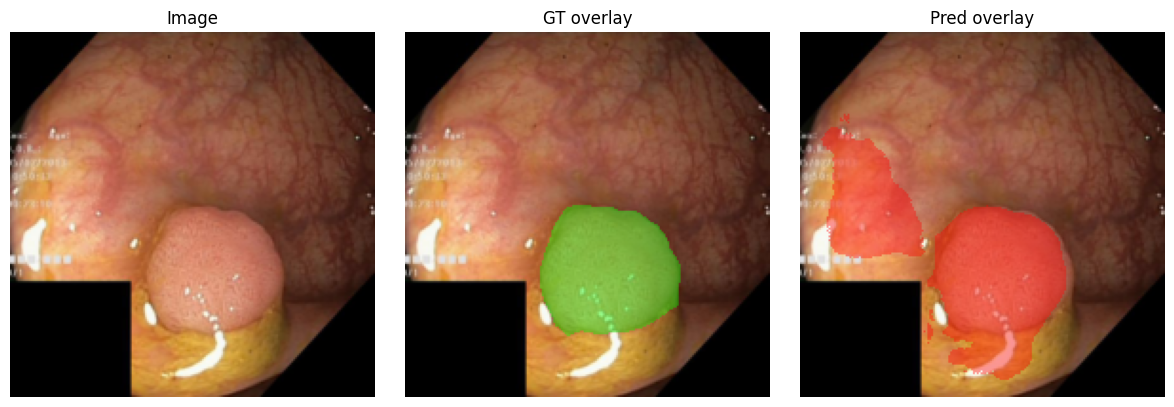

Test Dice (this batch): 0.6665489077568054


In [22]:
# Inference demo on one batch + overlay

model.eval()
x, y = next(iter(test_loader))
x = x.to(device)
y = y.to(device)

with torch.no_grad():
    logits = model(x)
    probs = torch.sigmoid(logits)
    pred = (probs >= 0.5).float()

i = 0
img = x[i].detach().cpu().permute(1,2,0).numpy()
gt  = y[i,0].detach().cpu().numpy().astype(bool)
pd  = pred[i,0].detach().cpu().numpy().astype(bool)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.title('Image'); plt.imshow(img); plt.axis('off')
plt.subplot(1, 3, 2); plt.title('GT overlay'); plt.imshow(overlay_mask(img, gt, color=(0,1,0))); plt.axis('off')
plt.subplot(1, 3, 3); plt.title('Pred overlay'); plt.imshow(overlay_mask(img, pd, color=(1,0,0))); plt.axis('off')
plt.tight_layout(); plt.show()

print('Test Dice (this batch):', dice_coef(torch.from_numpy(pd).float().view(1,1,*pd.shape), torch.from_numpy(gt).float().view(1,1,*gt.shape)).item())

## 10) Interpretability: Grad-CAM (Gradient-weighted Class Activation Mapping)

**Why it matters:** In medical AI, we need to understand **where** the model is looking to make predictions. This is critical for:
- Clinical trust and adoption
- Debugging model failures
- Discovering unexpected biases

Grad-CAM highlights which regions of an image most influence the model's prediction.

### How Grad-CAM works:
1. Forward pass: get predictions
2. Backward pass: compute gradients of target class w.r.t. feature maps
3. Weight feature maps by gradient importance
4. Generate heatmap showing "where the model is looking"

### Exercise: Implement Grad-CAM

Your task:
1. Implement `compute_gradcam(model, image, target_layer)` that returns a heatmap
2. The function should:
   - Register a hook to capture activations and gradients
   - Do a forward pass
   - Backpropagate from the output
   - Weight activations by gradients
   - Return a 2D heatmap

Hints:
- Use `register_forward_hook` and `register_full_backward_hook`
- Average gradients across spatial dimensions to get weights
- Apply ReLU to final heatmap (only positive evidence)

In [ ]:
# Exercise (TODO)
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
    def save_activation(self, module, input, output):
        # TODO: save output activations
        pass
        
    def save_gradient(self, module, grad_input, grad_output):
        # TODO: save gradients
        pass
    
    def __call__(self, x: torch.Tensor, class_idx: Optional[int] = None) -> np.ndarray:
        """
        Args:
            x: input tensor [1, C, H, W]
            class_idx: target class index (None = use predicted class)
        Returns:
            heatmap: numpy array [H, W] in range [0, 1]
        """
        # TODO: register hooks
        # TODO: forward pass
        # TODO: select target score
        # TODO: backward pass
        # TODO: compute weights from gradients
        # TODO: weighted combination of activations
        # TODO: apply ReLU and normalize
        raise NotImplementedError

In [23]:
# Solution
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
    def save_activation(self, module, input, output):
        self.activations = output.detach().clone()  # Clone to avoid in-place issues
        
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach().clone()  # Clone to avoid in-place issues
    
    def __call__(self, x: torch.Tensor, class_idx: Optional[int] = None) -> np.ndarray:
        """
        Args:
            x: input tensor [1, C, H, W]
            class_idx: target class index (None = use predicted class)
        Returns:
            heatmap: numpy array [H, W] in range [0, 1]
        """
        # Register hooks
        h1 = self.target_layer.register_forward_hook(self.save_activation)
        h2 = self.target_layer.register_full_backward_hook(self.save_gradient)
        
        # Forward pass
        self.model.eval()
        output = self.model(x)
        
        # For segmentation models, average spatial predictions to get "image-level" score
        if output.dim() == 4:  # [B, C, H, W]
            score = output.mean(dim=(2, 3))  # [B, C]
        else:
            score = output
        
        if class_idx is None:
            class_idx = score.argmax(dim=1).item()
        
        # Backward pass
        self.model.zero_grad()
        target = score[0, class_idx]
        target.backward()
        
        # Compute weights: global average pooling of gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]
        
        # Weighted combination
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # [1, 1, H', W']
        
        # Apply ReLU (only positive evidence) - use non-in-place version
        cam = torch.clamp(cam, min=0)
        
        # Upsample to input size
        cam = F.interpolate(cam, size=x.shape[2:], mode='bilinear', align_corners=False)
        
        # Normalize to [0, 1]
        cam = cam.squeeze().cpu().numpy()
        cam_min = cam.min()
        cam_max = cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)
        
        # Remove hooks
        h1.remove()
        h2.remove()
        
        return cam

def overlay_heatmap(image: np.ndarray, heatmap: np.ndarray, alpha: float = 0.4, colormap=plt.cm.jet) -> np.ndarray:
    """Overlay heatmap on image."""
    # Ensure image is [H, W, 3] in [0, 1]
    if image.shape[0] == 3:  # [3, H, W] -> [H, W, 3]
        image = np.transpose(image, (1, 2, 0))
    image = np.clip(image, 0, 1)
    
    # Apply colormap to heatmap
    heatmap_colored = colormap(heatmap)[..., :3]  # [H, W, 3]
    
    # Blend
    overlay = (1 - alpha) * image + alpha * heatmap_colored
    return np.clip(overlay, 0, 1)

### Demo: Grad-CAM on Segmentation Model

We'll visualize what regions the U-Net focuses on when making segmentation predictions.

**Note:** After running the training cells above, you need to re-run them to create a new model with `inplace=False` ReLU operations.

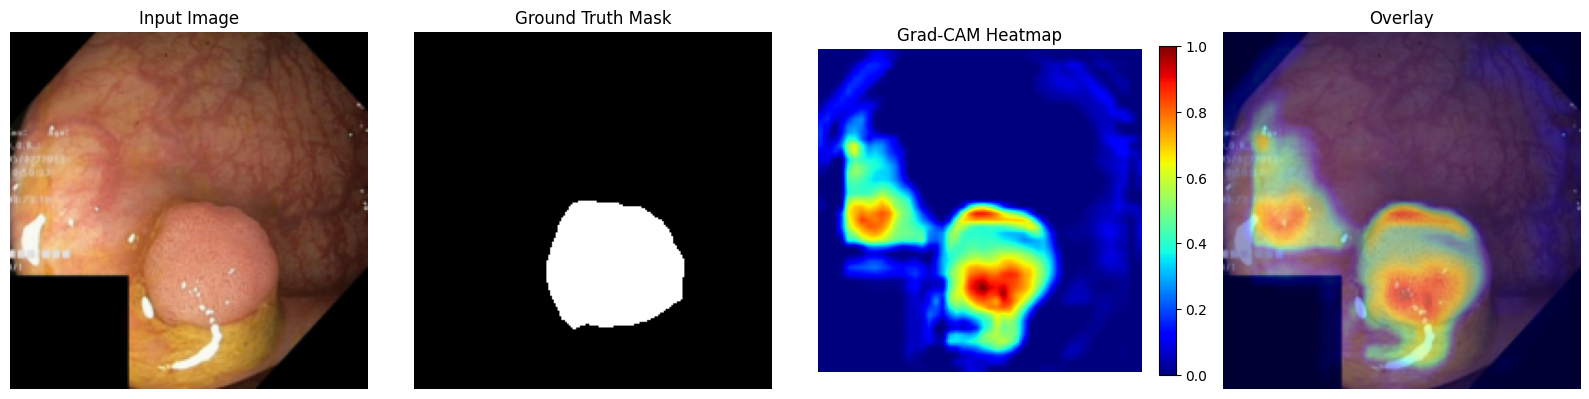

In [24]:
# Apply Grad-CAM to our trained segmentation model
# Target the last encoder layer (deepest features before bottleneck)

# IMPORTANT: Re-create and re-train the model with inplace=False
# If you just ran the cells above, the model should already be compatible
# Otherwise, re-run the training section first

gradcam = GradCAM(model, target_layer=model.enc3.net[-1])  # Last ReLU in enc3

# Get a test sample
x, y = next(iter(test_loader))
sample_img = x[0:1].to(device)  # [1, 3, H, W]
sample_mask = y[0:1].to(device)

# Compute Grad-CAM
cam = gradcam(sample_img, class_idx=0)  # class_idx=0 for binary segmentation

# Visualize
img_np = sample_img[0].cpu().numpy()
mask_np = sample_mask[0, 0].cpu().numpy()

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.title('Input Image')
plt.imshow(np.transpose(img_np, (1, 2, 0)))
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Ground Truth Mask')
plt.imshow(mask_np, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('Grad-CAM Heatmap')
plt.imshow(cam, cmap='jet')
plt.colorbar(fraction=0.046)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('Overlay')
plt.imshow(overlay_heatmap(img_np, cam))
plt.axis('off')

plt.tight_layout()
plt.show()

## 11) PhD-level extensions (suggested exercises)

Pick one and extend the notebook:

1. **3D volumes**: patch-based training, sliding-window inference, spacing-aware resampling.
2. **Domain shift**: train/val across hospitals/scanners, intensity standardization, test-time augmentation.
3. **Losses**: focal, Tversky, boundary losses; class imbalance handling.
4. **Uncertainty**: MC dropout, deep ensembles; calibration (ECE), reliability diagrams.
5. **Evaluation**: per-case Dice, Hausdorff distance (HD95), confidence intervals, proper aggregation.
6. **Reproducibility**: fixed splits, deterministic ops, seed control, config management.
7. **Frameworks**: MONAI pipelines, nnU-Net-style preprocessing, lightning training structure.
8. **Advanced interpretability**: Grad-CAM++, Integrated Gradients, attention mechanisms.